# Optimization of Log Loss — Part 1

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture introducing the **log loss**
(Week 1 — Derivatives and Optimization).

This notebook explains:

- the **coin-flip game** that motivates the log loss
- maximizing the win probability $G(P) = P^7(1-P)^3$ with calculus ($P = 0.7$)
- the **logarithm trick** that makes the optimization much easier
- the **log loss** $-\log G$ (negative log-likelihood) used in classification

This notebook follows the repository `GUIDELINES.md` template and continues directly from
*Optimization of Squared Loss* (the square loss); together they are the two key ML losses.

## 1. The coin-flip game

Toss a coin **10 times**; you win **only** if you get **7 heads followed by 3 tails**. You
may choose a (possibly biased) coin:

- **Coin 1:** $P(\text{H}) = 0.7$
- **Coin 2:** fair, $P(\text{H}) = 0.5$
- **Coin 3:** $P(\text{H}) = 0.3$

Which maximizes your chance of winning? Since flips are independent, the win probability is
$P(\text{H})^7 \cdot P(\text{T})^3$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

def win_prob(p):
    return p**7 * (1 - p)**3

for name, p in [("Coin 1 (0.7)", 0.7), ("Coin 2 (0.5)", 0.5), ("Coin 3 (0.3)", 0.3)]:
    print(f"{name}: P(win) = {p}^7 · {1-p:.1f}^3 = {win_prob(p):.6f}")
print("\n-> Coin 1 gives the highest chance of winning.")

Coin 1 (0.7): P(win) = 0.7^7 · 0.3^3 = 0.002224
Coin 2 (0.5): P(win) = 0.5^7 · 0.5^3 = 0.000977
Coin 3 (0.3): P(win) = 0.3^7 · 0.7^3 = 0.000075

-> Coin 1 gives the highest chance of winning.


## 2. The best coin among *all* coins

Coin 1 wins among the three, but is $0.7$ the best **possible** bias? Let a coin have
$P(\text{H}) = P$ and $P(\text{T}) = 1 - P$. The win probability is

$$
G(P) = P^7\,(1 - P)^3 .
$$

Maximize it by setting $G'(P) = 0$. Using the **product rule** and **chain rule**:

$$
G'(P) = 7P^6(1-P)^3 + P^7\cdot 3(1-P)^2\cdot(-1).
$$

Factoring gives a product whose zeros are $P = 0$, $P = 1$, and $P = 0.7$. The first two
mean "never heads" / "never tails" — impossible to win — so

$$
\boxed{\;P = 0.7.\;}
$$

Coin 1 really is the best possible coin.

In [2]:
P = sp.symbols('P', positive=True)
G = P**7 * (1 - P)**3
Gp = sp.diff(G, P)
print("G'(P) =", sp.factor(Gp))
print("candidates (G'(P)=0):", sp.solve(Gp, P))
print("-> discard P=0 and P=1 (can't win); optimal P = 0.7")

G'(P) = -P**6*(P - 1)**2*(10*P - 7)
candidates (G'(P)=0): [7/10, 1]
-> discard P=0 and P=1 (can't win); optimal P = 0.7


## 3. The logarithm trick

Differentiating $G$ directly was a lot of work. A simpler route: **take the logarithm**.
Because $\log$ is increasing, maximizing $\log G(P)$ is the same as maximizing $G(P)$.

Using $\log(ab) = \log a + \log b$ and $\log(a^k) = k\log a$:

$$
\log G(P) = \log\!\big(P^7 (1-P)^3\big) = 7\log P + 3\log(1-P).
$$

Now the derivative is easy (recall $\dfrac{d}{dP}\log P = \dfrac1P$):

$$
\frac{d}{dP}\log G = \frac{7}{P} - \frac{3}{1-P} = 0
\;\Rightarrow\; 7(1-P) - 3P = 0 \;\Rightarrow\; 7 - 10P = 0 \;\Rightarrow\; P = 0.7 .
$$

Same answer, far less algebra.

In [3]:
logG = 7*sp.log(P) + 3*sp.log(1 - P)
dlogG = sp.diff(logG, P)
print("d/dP log G =", sp.simplify(dlogG))
print("solve = 0:", sp.solve(dlogG, P), " -> P = 0.7 (same answer, easier)")

d/dP log G = (10*P - 7)/(P*(P - 1))
solve = 0: [7/10]  -> P = 0.7 (same answer, easier)


## 4. The log loss

Logarithms of probabilities are everywhere in machine learning. What we actually use is the
**negative** of $\log G$:

$$
\text{log loss} = -\log G(P) = -\big[7\log P + 3\log(1-P)\big].
$$

Why the minus sign? For $0 < P < 1$, $\log P$ is **negative**, so $-\log G$ is **positive**.
And instead of **maximizing** the (log-)likelihood, we **minimize** the log loss — the same
optimum, framed as a loss.

This is the **negative log-likelihood**, and it is the **log loss / cross-entropy** used in
**classification** (it returns in the perceptron and neural-network lectures).

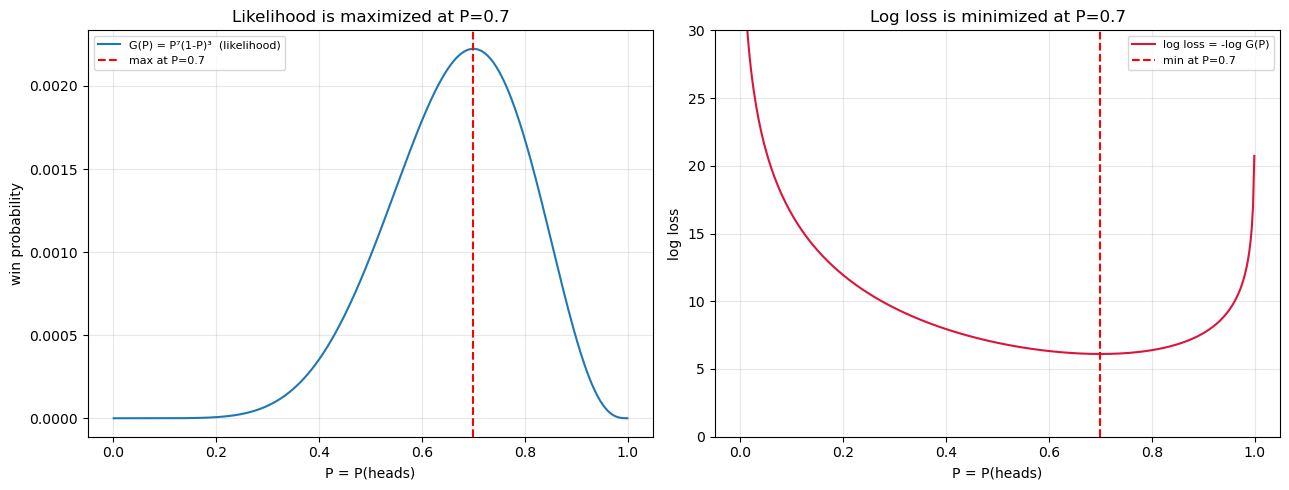

In [4]:
# the three curves: likelihood G, log-likelihood log G, and log loss -log G
ps = np.linspace(0.001, 0.999, 400)
G_ = ps**7 * (1 - ps)**3
logG_ = 7*np.log(ps) + 3*np.log(1 - ps)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(ps, G_, label="G(P) = P⁷(1-P)³  (likelihood)")
axes[0].axvline(0.7, color="red", ls="--", label="max at P=0.7")
axes[0].set_title("Likelihood is maximized at P=0.7")
axes[0].set_xlabel("P = P(heads)"); axes[0].set_ylabel("win probability")
axes[0].grid(True, alpha=0.3); axes[0].legend(fontsize=8)

axes[1].plot(ps, -logG_, color="crimson", label="log loss = -log G(P)")
axes[1].axvline(0.7, color="red", ls="--", label="min at P=0.7")
axes[1].set_title("Log loss is minimized at P=0.7")
axes[1].set_xlabel("P = P(heads)"); axes[1].set_ylabel("log loss")
axes[1].set_ylim(0, 30); axes[1].grid(True, alpha=0.3); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5. Exercises

### Basic
1. Write the win probability $G(P)$ for 7 heads and 3 tails.
2. Which coin (0.7, 0.5, 0.3) is best, and why?

### Intermediate
3. Maximize $G(P) = P^7(1-P)^3$ using the log trick.
4. Why does taking the logarithm not change the location of the maximum?

### Advanced
5. For $h$ heads and $t$ tails, show the optimal $P$ is $\dfrac{h}{h+t}$ (the observed
   frequency).
6. Explain why we use the **negative** log-likelihood as a loss, and why we **minimize** it.

## 6. Solutions / Checks

In [5]:
P = sp.symbols('P', positive=True)

# 3.
logG = 7*sp.log(P) + 3*sp.log(1-P)
print("3. log-trick optimum:", sp.solve(sp.diff(logG, P), P))

# 5. general h heads, t tails
h, t = sp.symbols('h t', positive=True)
LG = h*sp.log(P) + t*sp.log(1-P)
print("5. optimal P =", sp.simplify(sp.solve(sp.diff(LG, P), P)[0]), " = h/(h+t)")

print("\n1. G(P) = P⁷(1-P)³.")
print("2. Coin 1 (0.7): it gives the highest win probability (0.00222).")
print("4. log is strictly increasing, so it preserves the location of the maximum.")
print("6. log P < 0 for 0<P<1, so -log G > 0; minimizing -log G maximizes the likelihood.")

3. log-trick optimum: [7/10]
5. optimal P = h/(h + t)  = h/(h+t)

1. G(P) = P⁷(1-P)³.
2. Coin 1 (0.7): it gives the highest win probability (0.00222).
4. log is strictly increasing, so it preserves the location of the maximum.
6. log P < 0 for 0<P<1, so -log G > 0; minimizing -log G maximizes the likelihood.


## 7. Conclusion

- The coin game: to win with 7 heads and 3 tails, choose the coin maximizing $G(P) =
  P^7(1-P)^3$ — the optimum is $P = 0.7$ (the observed frequency).
- Direct calculus works (product + chain rule), but the **log trick** —
  $\log G = 7\log P + 3\log(1-P)$ — makes differentiation far simpler, giving $P = 0.7$.
- The **log loss** $-\log G$ (negative log-likelihood) turns "maximize likelihood" into
  "minimize a positive loss."
- For general counts the optimum is $\dfrac{h}{h+t}$ — and this log loss is the
  classification loss that reappears throughout the course.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/index (25).mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 1) lecture **optimization of log loss — part 1**. Key spoken points, lightly
cleaned (computed probabilities used where the audio rounded):

> Another key ML function is the log loss, seen via coin flips. Game: toss a coin 10 times
> and win only on 7 heads then 3 tails; you may pick a biased coin. Coin 1 ($P(H)=0.7$)
> gives $0.7^7\cdot0.3^3 = 0.00222$; coin 2 (fair) gives $0.5^{10} = 0.00097$; coin 3
> ($0.3$) gives $0.3^7\cdot0.7^3 \approx 0.000075$ — so coin 1 is best. Is $0.7$ the best of
> all coins? Let $P(H)=P$; the win probability is $G(P) = P^7(1-P)^3$. Maximizing with the
> product and chain rules gives candidates $P=0$, $P=1$, $P=0.7$; the first two can't win,
> so $P=0.7$. Easier: take the logarithm (maximizing $\log G$ equals maximizing $G$), so
> $\log G = 7\log P + 3\log(1-P)$; its derivative is $7/P - 3/(1-P) = 0$, giving $7(1-P) =
> 3P$, i.e. $P=0.7$. The log trick is very common in ML. What we really use is the negative,
> $-\log G$, the log loss — positive because $\log P < 0$ for $0<P<1$ — which we minimize. It
> appears throughout classification.